# Beamline Optimization - Initialization
This notebook performs sequential optimization of the UH beamline using custom modules and beam parameters.

Help for associated beamline element indexing: image.png

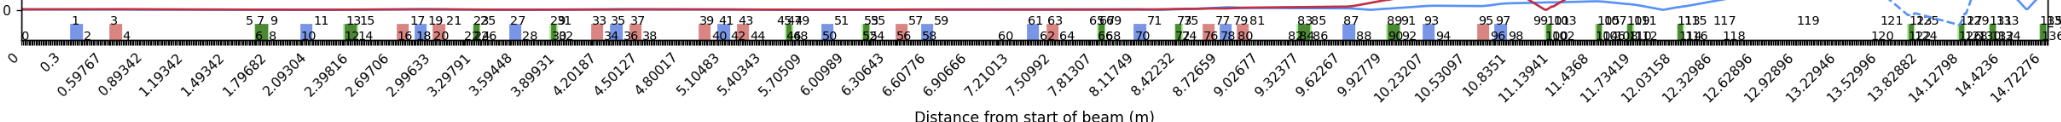

In [1]:
import os, sys
from pprint import pprint
# pprint(sys.path)

current_dir = os.path.abspath(os.getcwd())

project_root = os.path.abspath(os.path.join(current_dir, '..'))

if project_root not in sys.path:
    sys.path.insert(0, project_root)
pprint(sys.path)
# from backend.beamline import *

['C:\\Users\\yi_lu\\my_files\\research\\FELsim\\backend_orig',
 'C:\\Users\\yi_lu\\my_files\\research\\FELsim',
 'C:\\Users\\yi_lu\\programming_IDE\\PyCharm_2025.2.1\\plugins\\python-ce\\helpers\\pydev',
 'C:\\Users\\yi_lu\\programming_IDE\\PyCharm_2025.2.1\\plugins\\python-ce\\helpers\\jupyter_debug',
 'C:\\Users\\yi_lu\\programming_lang\\Anaconda\\envs\\felsim\\python311.zip',
 'C:\\Users\\yi_lu\\programming_lang\\Anaconda\\envs\\felsim\\DLLs',
 'C:\\Users\\yi_lu\\programming_lang\\Anaconda\\envs\\felsim\\Lib',
 'C:\\Users\\yi_lu\\programming_lang\\Anaconda\\envs\\felsim',
 '',
 'C:\\Users\\yi_lu\\AppData\\Roaming\\Python\\Python311\\site-packages',
 'C:\\Users\\yi_lu\\programming_lang\\Anaconda\\envs\\felsim\\Lib\\site-packages']


In [2]:
# Import Python modules
%matplotlib ipympl
import sys
import time
from pathlib import Path
import numpy as np
import pandas as pd
import sympy as sp
import sympy.plotting as plot

# Import Beam Dynamics modules
from ebeam import beam
from beamline import lattice, Beamline
from schematic import draw_beamline
from excelElements import ExcelElements
from beamOptimizer import beamOptimizer
from AlgebraicOptimization import AlgebraicOpti

In [3]:
# Initial Beam Parameters
Energy = 40  # MeV
f = 2856e6  # Hz
bunch_spread = 2  # ps
energy_std_percent = 0.5  # 0.3 % Energy spread from M. Hadmack Rev. Sci. Instrum. 84, 063302 (2013); doi: 10.1063/1.4809938 
h = 5e9  # 1/s

epsilon_n = 8  # pi.mm.mrad
x_std = 0.8  # mm
y_std = 0.8  # mm
nb_particles = 1000

relat = lattice(1,fringeType=None)
relat.setE(E=Energy)
norm = relat.gamma * relat.beta
epsilon = epsilon_n / norm
print(relat.gamma)
print(relat.beta)
print(epsilon)
x_prime_std = epsilon / x_std
y_prime_std = epsilon / y_std

tof_std = bunch_spread * 1e-9 * f
gen_tof = np.random.normal(0, tof_std, size=(nb_particles, 1))
energy_std = energy_std_percent * 10

ebeam = beam()
beam_dist = ebeam.gen_6d_gaussian(0, [x_std,x_prime_std,y_std,y_prime_std,tof_std,energy_std], nb_particles)
tof_dist = beam_dist[:,4] / f
beam_dist[:,5] += h * tof_dist


# MkV FEL Undulator matching
K = 1.2
lambda_u = 2.3  # Undulator period in cm

beta_ym = relat.gamma / (K * (2 * np.pi / (lambda_u * 1e-2)))
print(beta_ym)
y_std_m = np.sqrt(epsilon * 1e-6 * beta_ym)
print(y_std_m)
y_prime_std_m = np.sqrt(epsilon * 1e-6 / beta_ym) # Beam at waist so Gamma(z_w) = 1 / Beta(z_w)
print(y_prime_std_m)

79.2794183839214
0.9999204452035254
0.10091694227956337
0.2418394669906551
0.00015622323620773033
0.0006459790792284825


In [4]:
# Load Beamline from Excel
current_path = Path.cwd()


file_path = current_path.parents[1] / 'beam_excel' / 'Beamline_elements.xlsx'



excel = ExcelElements(file_path)
df = excel.get_dataframe()
beamlineUH = excel.create_beamline()
schem = draw_beamline()
line_UH = relat.changeBeamType("electron", Energy, beamlineUH)

# Optimizer and beamline truncation
print('Number of elements in beamline: ' + str(len(line_UH)))
segments = 138
line = line_UH[:segments]
opti = beamOptimizer(line, beam_dist)

Number of elements in beamline: 138


In [5]:
# Optimization - First Quadrupole Doublet

variables = {
    1: ["I", "current", lambda num:num],
    3: ["I2", "current", lambda num:num],
}
startPoint = {
    "I": {"bounds": (0,10), "start": 1},
    "I2": {"bounds": (0, 10), "start": 1},
}

objectives = {8: [{"measure": ["x", "alpha"], "goal": 0, "weight":1},
                  {"measure": ["x", "beta"], "goal": 0.1, "weight":0.0}],
              9: [{"measure": ["y", "alpha"], "goal": 0, "weight":1},
                  {"measure": ["y", "beta"], "goal": 0.1, "weight":0.5}]}

result = opti.calc("Nelder-Mead", variables, startPoint, objectives, plotBeam=False, printResults=True, plotProgress=False)

# old values
# line[1].current = 0.9989681933
# line[3].current = 1.044851479

degug beamOptimizer 194:  <bound method beamOptimizer._optiSpeed of <beamOptimizer.beamOptimizer object at 0x00000263C727AE10>> [1, 1]

x variables:
indice 1 new current value: 0.8505745765694884
indice 3 new current value: 1.055657920587691

y objectives:
indice 8: x alpha value of -0.0006589897520739881
indice 8: x beta value of 0.8327241815826523
indice 9: y alpha value of -0.0004566737978275167
indice 9: y beta value of 0.13381279099089868
Final difference: 0.0001430701384799421

Total time: 82.49432679999154 s
Total iterations: 59



In [24]:
# Optimization - First Chromacity Quad

variables = {10: ["I", "current", lambda num:num]}
startPoint = {"I": {"bounds": (0,10), "start": 1}}
objectives = {15: [{"measure": ["x", "dispersion"], "goal": 0, "weight": 1}]}
result = opti.calc("Nelder-Mead", variables, startPoint, objectives, plotBeam=False, printResults=True, plotProgress=False)


x variables:
indice 10 new current value: 3.5252929687500054

y objectives:
indice 15: x disper value of 1.0474018476239036e-08
Final difference: 1.097050630405967e-16

Total time: 63.680999100004556 s
Total iterations: 38



In [25]:
# Optimization - Quadrupole Triplet

truncated_line = line[:17]
# Add half a quad
#truncated_line.append(qpfLattice(current = 3.816604, length=0.0889/2))

variables = {
    16: ["I", "current", lambda num:num],
    18: ["I2", "current", lambda num:num],
    20: ["I3", "current", lambda num:num],
}
startPoint = {
    "I": {"bounds": (0,10), "start": 2},
    "I2": {"bounds": (0, 10), "start": 5},
    "I3": {"bounds": (0, 10), "start": 3},
}

objectives = {25: [{"measure": ["x", "alpha"], "goal": 0, "weight":1},
                  {"measure": ["x", "beta"], "goal": 0.1, "weight":0.5}],
              26: [{"measure": ["y", "alpha"], "goal": 0, "weight":1},
                  {"measure": ["y", "beta"], "goal": 0.1, "weight":0.5}]}     

result = opti.calc("Nelder-Mead", variables, startPoint, objectives, plotBeam=False, printResults=True, plotProgress=False)

# old values
# line[16].current = 2.4
# line[18].current = 5.108214683
# line[20].current = 3.142089844


x variables:
indice 16 new current value: 2.049876578106943
indice 18 new current value: 4.907080358576351
indice 20 new current value: 3.523723567018135

y objectives:
indice 25: x alpha value of 3.6005994767039095e-06
indice 25: x beta value of 0.021277546338776612
indice 26: y alpha value of -5.644208344637761e-05
indice 26: y beta value of 0.012209714921513836
Final difference: 0.0017380417577861124

Total time: 200.2458304000029 s
Total iterations: 113



In [26]:
# Optimization - Second Chromacity Quad

variables = {27: ["I", "current", lambda num:num]}
startPoint = {"I": {"bounds": (0,10), "start": 1}}
objectives = {32: [{"measure": ["x", "dispersion"], "goal": 0, "weight": 1}]}
result = opti.calc("Nelder-Mead", variables, startPoint, objectives, plotBeam=False, printResults=True, plotProgress=False)


x variables:
indice 27 new current value: 4.518261718750008

y objectives:
indice 32: x disper value of 4.4088604801838483e-07
Final difference: 1.9438050733726953e-13

Total time: 73.5503458000021 s
Total iterations: 40



In [27]:
# Optimization - Double Quadrupole Triplet

variables = {
    37: ["I", "current", lambda num:num],
    35: ["I2", "current", lambda num:num],
    33: ["I3", "current", lambda num:num],
}
startPoint = {
    "I": {"bounds": (0,10), "start": 2},
    "I2": {"bounds": (0, 10), "start": 2},
    "I3": {"bounds": (0, 10), "start": 2},
}
objectives = {
    37: [
        {"measure": ["x", "alpha"], "goal": 0, "weight": 1},
        {"measure": ["y", "alpha"], "goal": 0, "weight": 1},
        {"measure": ["x", "envelope"], "goal": 2.0, "weight": 1},
        {"measure": ["y", "envelope"], "goal": 2.0, "weight": 1}
    ]
}
result = opti.calc("Nelder-Mead", variables, startPoint, objectives, plotBeam=False, printResults=True, plotProgress=False)

line[43].current = line[33].current
line[41].current = line[35].current
line[39].current = line[37].current


x variables:
indice 37 new current value: 0.41816137233384565
indice 35 new current value: 2.81686719500714
indice 33 new current value: 2.7043409800827067

y objectives:
indice 37: x alpha value of -0.01774775347155273
indice 37: y alpha value of -0.004256625480855884
indice 37: x envelope value of 0.9630235743324365
indice 37: y envelope value of 1.6187667049483725
Final difference: 0.3052480085649921

Total time: 225.18999640000402 s
Total iterations: 142



In [28]:
# Optimization - Third Chromacity Quad

variables = {50: ["I", "current", lambda num:num]}
startPoint = {"I": {"bounds": (0,10), "start": 1}}
objectives = {55: [{"measure": ["x", "dispersion"], "goal": 0, "weight": 1}]}
result = opti.calc("Nelder-Mead", variables, startPoint, objectives, plotBeam=False, printResults=True, plotProgress=False)



x variables:
indice 50 new current value: 4.620117187500008

y objectives:
indice 55: x disper value of 1.3390413268547888e-06
Final difference: 3.903537641202235e-14

Total time: 57.28861429999233 s
Total iterations: 40



In [29]:
# Optimization - Quadrupole Doublet and Interaction Point (z = 7.11 m, end of element index = 59)

variables = {
    56: ["I", "current", lambda num:num],
    58: ["I2", "current", lambda num:num],
}
startPoint = {
    "I": {"bounds": (0,10), "start": 2},
    "I2": {"bounds": (0, 10), "start": 2},
}

objectives = {
    59: [
        {"measure": ["x", "envelope"], "goal": 0.0, "weight": 1},
        {"measure": ["y", "envelope"], "goal": 0.0, "weight": 1}
    ]
}

result = opti.calc("Nelder-Mead", variables, startPoint, objectives, plotBeam=False, printResults=True, plotProgress=False)


x variables:
indice 56 new current value: 3.1209885646231776
indice 58 new current value: 3.307039089321669

y objectives:
indice 59: x envelope value of 0.026097258186227955
indice 59: y envelope value of 0.05152031671487929
Final difference: 0.0016677049596200563

Total time: 115.177826500003 s
Total iterations: 80



In [30]:
# Optimization - Quadrupole Doublet

variables = {
    61: ["I", "current", lambda num:num],
    63: ["I2", "current", lambda num:num],
}
startPoint = {
    "I": {"bounds": (0,10), "start": 2},
    "I2": {"bounds": (0, 10), "start": 2},
}

objectives = {
    68: [{"measure": ["x", "alpha"], "goal": 0, "weight": 1},
        {"measure": ["x", "beta"], "goal": 0.1, "weight": 0.5}],
    69: [{"measure": ["y", "alpha"], "goal": 0, "weight": 1},
         {"measure": ["y", "beta"], "goal": 0.1, "weight": 0.5}]
}

result = opti.calc("Nelder-Mead", variables, startPoint, objectives, plotBeam=False, printResults=True, plotProgress=False)



x variables:
indice 61 new current value: 5.165590138243321
indice 63 new current value: 4.042066371061926

y objectives:
indice 68: x alpha value of -3.2303163243145915e-05
indice 68: x beta value of 0.08745796758243803
indice 69: y alpha value of 4.62179165073889e-05
indice 69: y beta value of 0.01527245683343394
Final difference: 0.000917008188423227

Total time: 156.86693070002366 s
Total iterations: 109



In [31]:
# Optimization - Fourth Chromacity Quad

variables = {70: ["I", "current", lambda num:num]}
startPoint = {"I": {"bounds": (0,10), "start": 1}}
objectives = {75: [{"measure": ["x", "dispersion"], "goal": 0, "weight": 1}]}
result = opti.calc("Nelder-Mead", variables, startPoint, objectives, plotBeam=False, printResults=True, plotProgress=False)


x variables:
indice 70 new current value: 4.743359375000008

y objectives:
indice 75: x disper value of 5.864696388812628e-07
Final difference: 2.1894429504713987e-13

Total time: 56.685948199999984 s
Total iterations: 40



In [32]:
# Optimization - Quadrupole Triplet

variables = {
    76: ["I", "current", lambda num:num],
    78: ["I2", "current", lambda num:num],
    80: ["I3", "current", lambda num:num],
}
startPoint = {
    "I": {"bounds": (0,10), "start": 2},
    "I2": {"bounds": (0, 10), "start": 2},
    "I3": {"bounds": (0, 10), "start": 2},
}

objectives = {
    85: [{"measure": ["x", "alpha"], "goal": 0, "weight": 1},
        {"measure": ["x", "beta"], "goal": 0.1, "weight": 0.5}],
    86: [{"measure": ["y", "alpha"], "goal": 0, "weight": 1},
         {"measure": ["y", "beta"], "goal": 0.1, "weight": 0.5}]
}

result = opti.calc("Nelder-Mead", variables, startPoint, objectives, plotBeam=False, printResults=True, plotProgress=False)


x variables:
indice 76 new current value: 3.9128005357994375
indice 78 new current value: 4.1622350525459355
indice 80 new current value: 0.2602564392403409

y objectives:
indice 85: x alpha value of 0.0005462483315836777
indice 85: x beta value of 0.07951087414058455
indice 86: y alpha value of 0.00023842695049621046
indice 86: y beta value of 0.08211837895853792
Final difference: 9.253338985679854e-05

Total time: 213.61665650000214 s
Total iterations: 157



In [33]:
# Optimization - Fifth Chromacity Quad

variables = {87: ["I", "current", lambda num:num]}
startPoint = {"I": {"bounds": (0,10), "start": 1}}
objectives = {92: [{"measure": ["x", "dispersion"], "goal": 0, "weight": 1}]}
result = opti.calc("Nelder-Mead", variables, startPoint, objectives, plotBeam=False, printResults=True, plotProgress=False)


x variables:
indice 87 new current value: 4.044531250000007

y objectives:
indice 92: x disper value of 3.326650284518955e-07
Final difference: 6.032145084706708e-14

Total time: 61.89133749998291 s
Total iterations: 40



In [34]:
# Optimization - Quadrupole Triplet and MkIII undulator start (z = 12.389 m , end of element index = 117)

variables = {
    93: ["I", "current", lambda num:num],
    95: ["I2", "current", lambda num:num],
    97: ["I3", "current", lambda num:num],
}
startPoint = {
    "I": {"bounds": (0,10), "start": 2},
    "I2": {"bounds": (0, 10), "start": 2},
    "I3": {"bounds": (0, 10), "start": 2},
}
objectives = {
    117: [
        {"measure": ["x", "alpha"], "goal": 0, "weight": 1},
        {"measure": ["y", "alpha"], "goal": 0, "weight": 1},
        {"measure": ["x", "beta"], "goal": beta_ym, "weight": 1},
        {"measure": ["y", "beta"], "goal": beta_ym, "weight": 1}
    ]
}
result = opti.calc("Nelder-Mead", variables, startPoint, objectives, plotBeam=False, printResults=True, plotProgress=False)


#indice 93 new current value: 2.1275944045328767
#indice 95 new current value: 1.543397467601471
#indice 97 new current value: 0.3798657737076452


x variables:
indice 93 new current value: 8.765329493463934e-06
indice 95 new current value: 3.3122130383016444
indice 97 new current value: 2.569540956558005

y objectives:
indice 117: x alpha value of 0.016330886723597785
indice 117: y alpha value of -0.00018950959190661376
indice 117: x beta value of 0.22850991645685467
indice 117: y beta value of 0.03311710696746446
Final difference: 0.011002330660551646

Total time: 601.3435431000253 s
Total iterations: 361



Simulating Beamline:  98%|█████████▊| 1514/1550 [00:06<00:00]


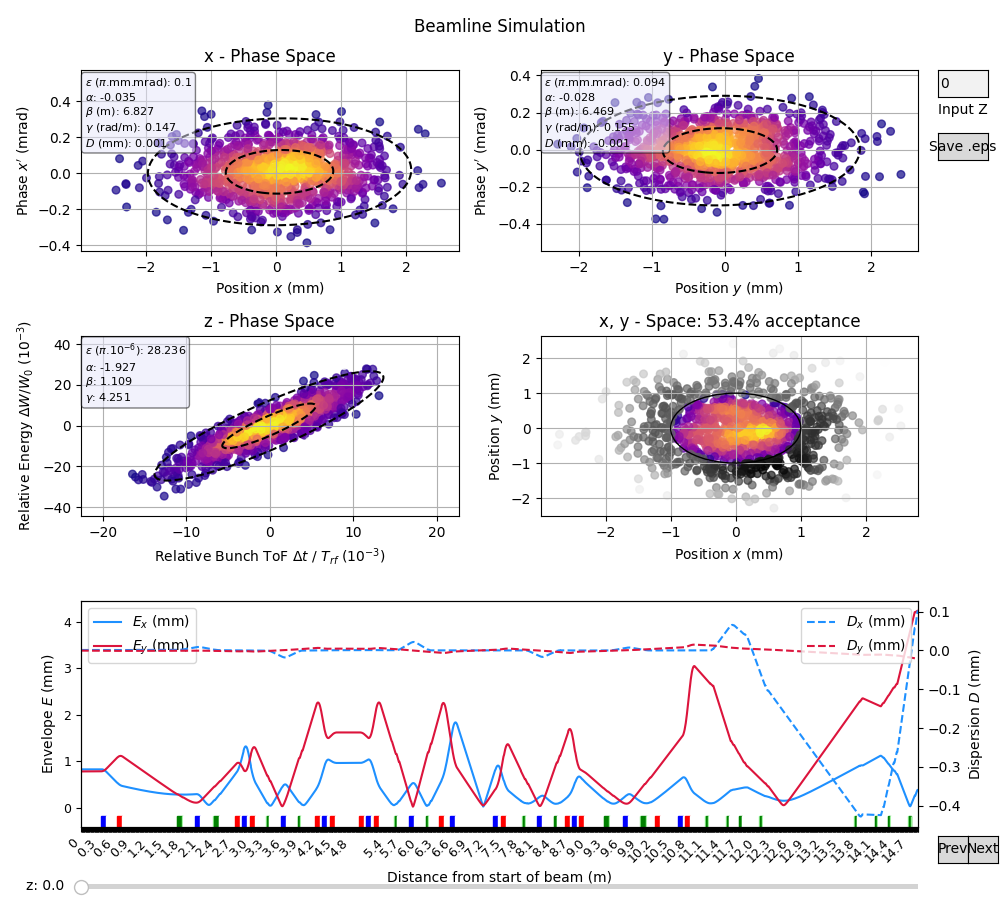

,$\epsilon$ ($\pi$.mm.mrad),$\alpha$,$\beta$ (m),$\gamma$ (rad/m),$D$ (mm),$D^{\prime}$ (mrad),$\phi$ (deg),Envelope $E$ (mm)
x,"[0.09991127878666198, 0.09991127878666199, 0.0...","[-0.034957256305042435, -0.03642384204713472, ...","[6.826890382419666, 6.827604193403187, 6.82834...","[0.1466585742092305, 0.14665857420923048, 0.14...","[0.0010961480573783802, 0.001101261923827499, ...","[0.0005113866449118876, 0.0005113866449118876,...","[-89.70018553504912, -89.68764156442722, -89.6...","[0.8258833744808722, 0.8259265500104039, 0.825..."
y,"[0.09436766594501311, 0.09436766594501313, 0.0...","[-0.028325906793223703, -0.029872975129705607,...","[6.46902488658986, 6.469606875409091, 6.470219...","[0.15470683364818996, 0.15470683364818993, 0.1...","[-0.0005196626347310757, -0.000525518875667796...","[-0.0005856240936719937, -0.000585624093671993...","[-89.74297915444556, -89.72896731253182, -89.7...","[0.7813237353924993, 0.7813588806778644, 0.781..."
z,"[28.23647842817908, 28.236478428179048, 28.236...","[-1.9267857789032177, -1.9267221438560873, -1....","[1.1086070084966224, 1.108549321415334, 1.1084...","[4.25083316420152, 4.250833164201525, 4.250833...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-25.402991971666776, -25.402270988277923, -25...","[5.59492250891315, 5.594776939317295, 5.594631..."


In [35]:
# Display Optimized Beamline

%matplotlib ipympl
acceptance = {"shape":'circle', "radius":1, "origin":[0,0]}
schem.plotBeamPositionTransform(beam_dist, line, 0.01, plot=True, showIndice=False, 
                                defineLim=False, matchScaling=False, shape=acceptance, scatter=True)

